##Install Required Libraries

In [1]:
!pip install opencv-python tensorflow scikit-learn matplotlib seaborn

##Import Libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import KFold

##Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
datasetpath='/content/drive/MyDrive/Thesis_Model_train/Copy of Chest-CT-Scan images Dataset.zip'
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 150

In [5]:
import zipfile

# Define the extraction path
extraction_path = '/content/Dataset'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(datasetpath, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped successfully to {extraction_path}")

Dataset unzipped successfully to /content/Dataset


In [6]:
import os

base_dir = extraction_path

train_dir = os.path.join(base_dir, 'Data', 'train')
valid_dir = os.path.join(base_dir, 'Data', 'valid')
test_dir = os.path.join(base_dir, 'Data', 'test')

print(f"Train directory: {train_dir}")
print(f"Validation directory: {valid_dir}")
print(f"Test directory: {test_dir}")

Train directory: /content/Dataset/Data/train
Validation directory: /content/Dataset/Data/valid
Test directory: /content/Dataset/Data/test


##Preprocessing Functions

In [7]:
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess_input
import cv2
import numpy as np

def apply_median_filter(image):
    return cv2.medianBlur(image, 5)

def apply_histogram_equalization(image):
    return cv2.equalizeHist(image)

def apply_morphological_ops(image):
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)
    return closing

# The custom filtering pipeline
def apply_custom_filters(image):
    # Ensure image is in uint8 for OpenCV operations if it's coming from ImageDataGenerator as float
    # ImageDataGenerator can output float32 in range [0, 255] if no rescale is applied.
    # Convert to uint8 for OpenCV processing
    img_uint8 = image.astype(np.uint8)

    # Convert to grayscale for median filter, histogram equalization, and morphological operations
    img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Apply custom filters
    img1 = apply_median_filter(img_gray)
    img2 = apply_histogram_equalization(img1)
    img3 = apply_morphological_ops(img2)

    # Convert back to RGB for consistency with InceptionV3 input
    processed_image_rgb = cv2.cvtColor(img3, cv2.COLOR_GRAY2RGB)

    # Return as float32 in range [0, 255] which `inception_preprocess_input` expects
    return processed_image_rgb.astype(np.float32)

# Unified preprocessing pipeline for InceptionV3
def full_inception_preprocessing_pipeline(image):
    # Apply custom filters first
    filtered_image = apply_custom_filters(image)
    # Then apply InceptionV3 specific preprocessing
    preprocessed_inception = inception_preprocess_input(filtered_image)
    return preprocessed_inception

### Example of Resizing with `tf.image.resize`

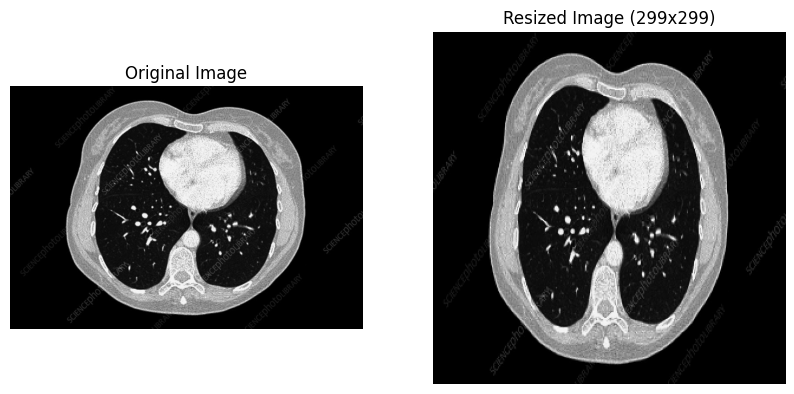

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Load a sample image
# The original code relied on 'train_data' which is defined later, causing a NameError.
# This modified code will directly find a sample image from the training directory.

train_dir = '/content/Dataset/Data/train'

img_path_for_resize_demo = None
# Iterate through class folders to find the first image
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)
    if os.path.isdir(class_path):
        images_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images_in_class:
            img_path_for_resize_demo = os.path.join(class_path, images_in_class[0])
            break

if img_path_for_resize_demo is None:
    raise FileNotFoundError("Could not find any sample image in the training directory.")

original_image = tf.io.read_file(img_path_for_resize_demo)
original_image = tf.image.decode_image(original_image, channels=3)

# Resize the image using tf.image.resize to IMG_SIZE
resized_image = tf.image.resize(original_image, [IMG_SIZE, IMG_SIZE])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image.numpy().astype('uint8')) # Convert to numpy and uint8 for display
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Resized Image ({IMG_SIZE}x{IMG_SIZE})")
plt.imshow(resized_image.numpy().astype('uint8')) # Convert to numpy and uint8 for display
plt.axis('off')

plt.show()

##Data Augmentation

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=full_inception_preprocessing_pipeline,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=full_inception_preprocessing_pipeline
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = valid_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    shuffle=False,
    class_mode='categorical'
)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


##Show Preprocessing Step Image

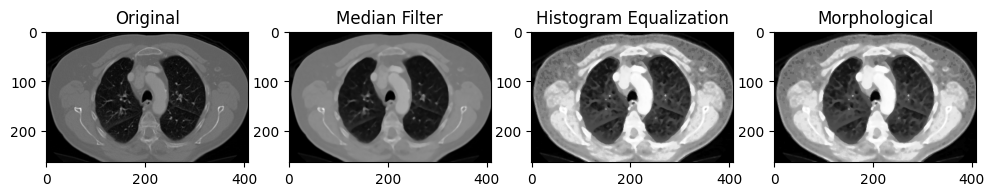

In [11]:
sample_img_path = train_data.filepaths[0]
img = cv2.imread(sample_img_path)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Median
median = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),5)
plt.subplot(1,4,2)
plt.title("Median Filter")
plt.imshow(median, cmap='gray')

# HE
he = cv2.equalizeHist(median)
plt.subplot(1,4,3)
plt.title("Histogram Equalization")
plt.imshow(he, cmap='gray')

# Morphology
kernel = np.ones((3,3), np.uint8)
mo = cv2.morphologyEx(he, cv2.MORPH_CLOSE, kernel)
plt.subplot(1,4,4)
plt.title("Morphological")
plt.imshow(mo, cmap='gray')

plt.show()

## build convNexT model

## Build ConvNeXt Model

In [12]:
from tensorflow.keras.applications import ConvNeXtBase

NUM_CLASSES = train_data.num_classes

# Load the pre-trained ConvNeXtBase model
convnext_base = ConvNeXtBase(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the base model layers initially
for layer in convnext_base.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
x = convnext_base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

convnext_model = Model(inputs=convnext_base.input, outputs=output)

# Compile the model
convnext_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

convnext_model.summary()

350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 299, 299,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 74, 74,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │      6,400 │ add[0][0]         │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        128 │ convnext_base_st

 Total params: 88,161,540 (336.31 MB)

 Trainable params: 593,028 (2.26 MB)

 Non-trainable params: 87,568,512 (334.05 MB)

## Callbacks and Class Weights

In [13]:
# Define callbacks
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.2, patience=5, monitor='val_loss', min_lr=1e-7),
]

# Compute class weights for handling potential class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


## Initial Model Training

In [14]:
history = convnext_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3605 - loss: 1.7038 - val_accuracy: 0.3750 - val_loss: 1.3077 - learning_rate: 1.0000e-04
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4372 - loss: 1.4271 - val_accuracy: 0.3889 - val_loss: 1.2466 - learning_rate: 1.0000e-04
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5057 - loss: 1.2016 - val_accuracy: 0.4444 - val_loss: 1.2008 - learning_rate: 1.0000e-04
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5416 - loss: 1.1269 - val_accuracy: 0.4583 - val_loss: 1.1657 - learning_rate: 1.0000e-04
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5840 - loss: 1.0575 - val_accuracy: 0.5000 - val_loss: 1.1269 - learning_rate: 1.0000e-04
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6297 - loss: 0.9218 - val_accuracy: 0.5278 - val_loss: 1.0863 - learning_rate: 1.0000e-04
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6476 

## Fine-Tuning the Model

In [22]:
# Unfreeze some layers for fine-tuning
# We'll unfreeze the last few blocks of the ConvNeXtBase model
for layer in convnext_base.layers[-50:]:
    layer.trainable = True

# Re-compile the model with a lower learning rate for fine-tuning
convnext_model.compile(
    optimizer=Adam(learning_rate=1e-5), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

convnext_model.summary()

fine_tune_history = convnext_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=50, # Additional epochs for fine-tuning
    callbacks=callbacks,
    class_weight=class_weights
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 299, 299,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 74, 74,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │      6,400 │ add[0][0]         │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 74, 74,    │        128 │ convnext_base_st

 Total params: 88,161,540 (336.31 MB)

 Trainable params: 36,520,068 (139.31 MB)

 Non-trainable params: 51,641,472 (197.00 MB)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.8695 - loss: 0.3376 - val_accuracy: 0.8333 - val_loss: 0.5161 - learning_rate: 1.0000e-05
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8711 - loss: 0.3235 - val_accuracy: 0.8194 - val_loss: 0.5025 - learning_rate: 1.0000e-05
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8499 - loss: 0.3725 - val_accuracy: 0.8333 - val_loss: 0.4993 - learning_rate: 1.0000e-05
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8728 - loss: 0.3155 - val_accuracy: 0.8194 - val_loss: 0.4996 - learning_rate: 1.0000e-05
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8842 - loss: 0.3171 - val_accuracy: 0.8194 - val_loss: 0.5043 - learning_rate: 1.0000e-05
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8728 - loss: 0.3293 - val_accuracy: 0.8472 - val_loss: 0.5000 - learning_rate: 1.0000e-05
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8809 - loss

## Accuracy & Loss Graph

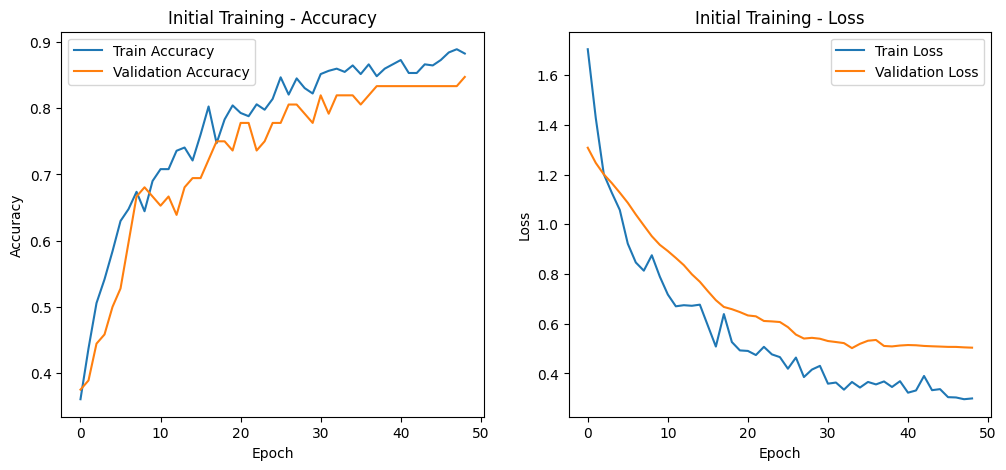

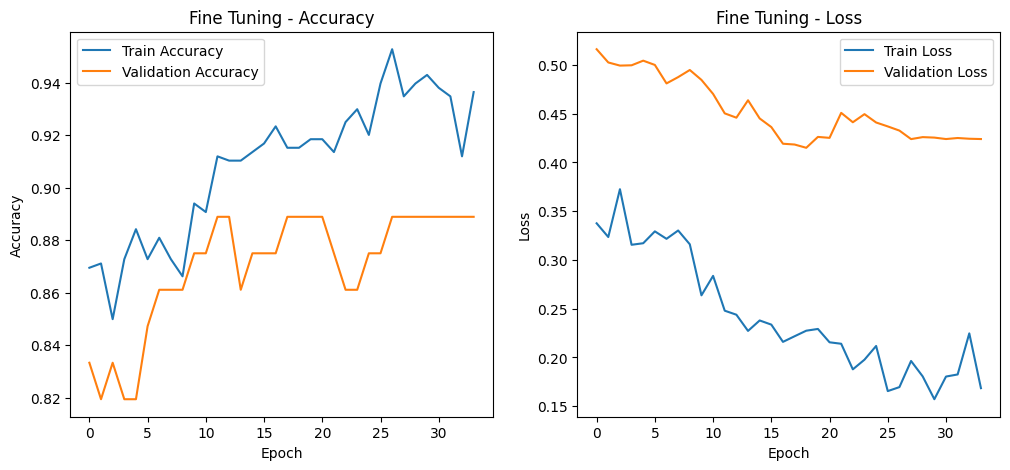

In [23]:
def plot_training(history, title="Training Performance"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_training(history, "Initial Training")
plot_training(fine_tune_history, "Fine Tuning")

## Model Evaluation

In [24]:
test_loss, test_acc = convnext_model.evaluate(test_data)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

315/315 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7587 - loss: 0.6146
Test Accuracy: 75.87%
Test Loss: 0.6146


## Evaluation Metrics: Classification Report

In [25]:
test_data.reset()
pred = convnext_model.predict(test_data)
y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

class_names_list = list(test_data.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names_list))

315/315 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step
                         precision    recall  f1-score   support

         adenocarcinoma       0.76      0.70      0.73       120
   large.cell.carcinoma       0.56      0.98      0.71        51
                 normal       0.96      0.93      0.94        54
squamous.cell.carcinoma       0.89      0.61      0.72        90

               accuracy                           0.76       315
              macro avg       0.79      0.80      0.78       315
           weighted avg       0.80      0.76      0.76       315



## Confusion Matrix

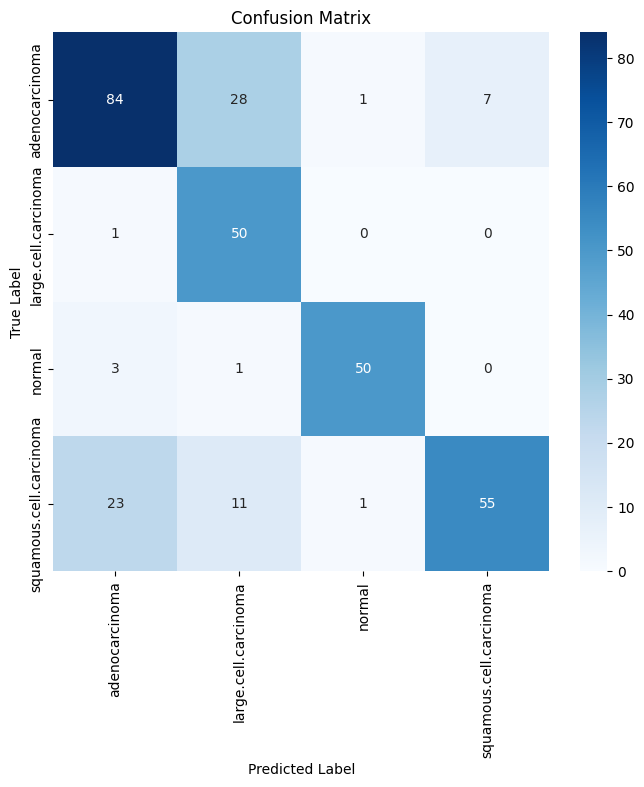

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_list,
            yticklabels=class_names_list)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC Curve + AUC

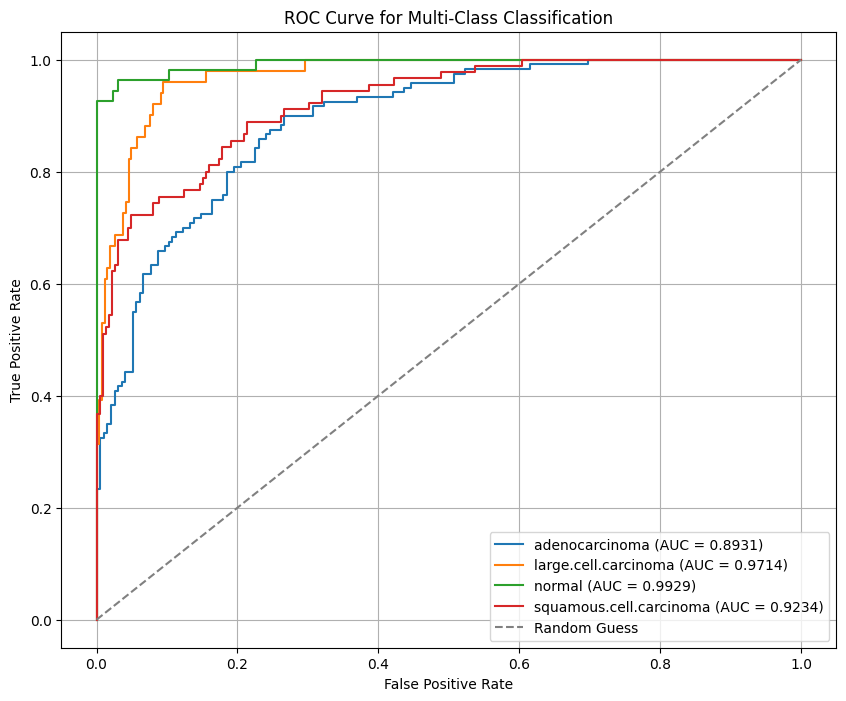

In [27]:
from sklearn.preprocessing import LabelBinarizer

# Binarize the true labels for ROC calculation
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(y_true)

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names_list[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()